<a href="https://colab.research.google.com/github/HemanthSelva/regression-models-ml/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression & Logistic Regression
### With MSE and R-Squared Score — External Dataset (CSV Upload)
---

## Step 1: Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load External Dataset

> **Dataset:** House Price Dataset — uploaded manually as CSV
>
> **Columns:** longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, Price
>
> - **Linear Regression**  — Predict `Price` (continuous output)
> - **Logistic Regression** — Predict `High/Low Price` (binary: Price >= median)

In [15]:
# Upload CSV file manually from your device
from google.colab import files
import io

uploaded = files.upload()  # Click the button and upload house_price.csv

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Dataset loaded successfully!')
print(f'File     : {filename}')
print(f'Shape    : {df.shape}')
print(f'Columns  : {list(df.columns)}')
df.head()

Saving house_price.csv to house_price (1).csv
Dataset loaded successfully!
File     : house_price (1).csv
Shape    : (200, 6)
Columns  : ['Area_sqft', 'Bedrooms', 'House_Age', 'Distance_to_City_km', 'Has_Garage', 'Price']


,Area_sqft,Bedrooms,House_Age,Distance_to_City_km,Has_Garage,Price
0,2418.3,1,18,8.1,0,279182.18
1,3176.5,1,38,13.2,0,334519.70
2,781.1,2,33,18.5,0,69791.00
3,1758.6,4,38,9.1,0,192142.39
4,2776.4,2,28,10.9,0,329775.44


## Step 3: Exploratory Data Analysis (EDA)

In [16]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            200 non-null    float64
 1   Bedrooms             200 non-null    int64  
 2   House_Age            200 non-null    int64  
 3   Distance_to_City_km  200 non-null    float64
 4   Has_Garage           200 non-null    int64  
 5   Price                200 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 9.5 KB
None

Missing Values:
Area_sqft              0
Bedrooms               0
House_Age              0
Distance_to_City_km    0
Has_Garage             0
Price                  0
dtype: int64

Statistical Summary:


,Area_sqft,Bedrooms,House_Age,Distance_to_City_km,Has_Garage,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1992.446500,3.455000,21.670000,15.511000,0.485000,248591.715900
std,849.370677,1.718353,11.092172,8.651545,0.501029,106604.245029
min,503.500000,1.000000,1.000000,1.000000,0.000000,50000.000000
25%,1311.775000,2.000000,13.000000,8.050000,0.000000,166017.512500
50%,1954.950000,3.000000,22.000000,15.400000,0.000000,250713.185000
75%,2728.375000,5.000000,31.000000,22.825000,1.000000,335080.770000
max,3463.000000,6.000000,40.000000,30.000000,1.000000,453832.100000


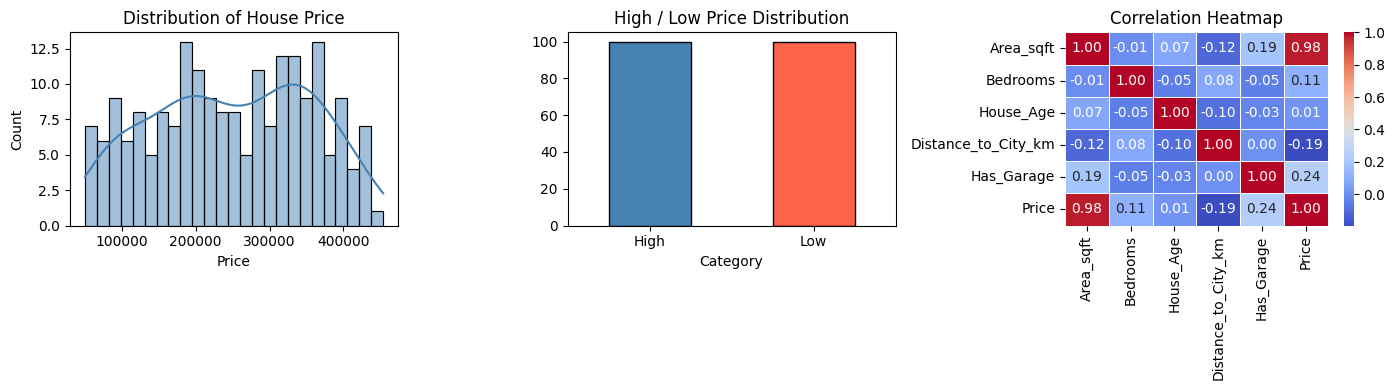

In [17]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['Price'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of House Price')
plt.xlabel('Price')

plt.subplot(1, 3, 2)
label = df['Price'].apply(lambda x: 'High' if x >= df['Price'].median() else 'Low')
label.value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('High / Low Price Distribution')
plt.xlabel('Category')
plt.xticks(rotation=0)

plt.subplot(1, 3, 3)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [18]:
df_encoded = df.copy()
le = LabelEncoder()
categorical_cols = df_encoded.select_dtypes(include='object').columns
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

if len(categorical_cols) > 0:
    print(f'Encoded columns: {list(categorical_cols)}')
else:
    print('No categorical columns found — no encoding needed.')

# Features
X = df_encoded.drop(columns=['Price'])

# Target — Linear Regression (continuous)
y_linear = df_encoded['Price']

# Target — Logistic Regression (binary: 1 = High, 0 = Low)
y_logistic = (df_encoded['Price'] >= df_encoded['Price'].median()).astype(int)

print(f'\nFeatures       : {list(X.columns)}')
print(f'Features shape : {X.shape}')
print(f'Linear target  : Price (continuous)')
print(f'Logistic target: High(1) / Low(0)  |  {y_logistic.value_counts().to_dict()}')

No categorical columns found — no encoding needed.

Features       : ['Area_sqft', 'Bedrooms', 'House_Age', 'Distance_to_City_km', 'Has_Garage']
Features shape : (200, 5)
Linear target  : Price (continuous)
Logistic target: High(1) / Low(0)  |  {1: 100, 0: 100}


---
# Part 1: Linear Regression
### Goal — Predict House Price (Continuous Output)

## Step 5A: Train-Test Split and Model Training

In [19]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y_linear, test_size=0.2, random_state=42
)

print(f'Train size : {X_train_lr.shape[0]} samples')
print(f'Test size  : {X_test_lr.shape[0]} samples')

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

print('\nLinear Regression model trained successfully!')

Train size : 160 samples
Test size  : 40 samples

Linear Regression model trained successfully!


## Step 5B: Predictions and Evaluation

In [20]:
y_pred_lr = lr_model.predict(X_test_lr)

mse_lr  = mean_squared_error(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test_lr, y_pred_lr)

print('=' * 48)
print('       LINEAR REGRESSION — METRICS')
print('=' * 48)
print(f'  Mean Squared Error  (MSE)  : {mse_lr:.4f}')
print(f'  Root Mean Sq. Error (RMSE) : {rmse_lr:.4f}')
print(f'  R-Squared Score     (R2)   : {r2_lr:.4f}')
print('=' * 48)
print(f'\n  Interpretation: Model explains {r2_lr*100:.2f}% of variance in House Price.')

       LINEAR REGRESSION — METRICS
  Mean Squared Error  (MSE)  : 250430249.8457
  Root Mean Sq. Error (RMSE) : 15824.9881
  R-Squared Score     (R2)   : 0.9765

  Interpretation: Model explains 97.65% of variance in House Price.


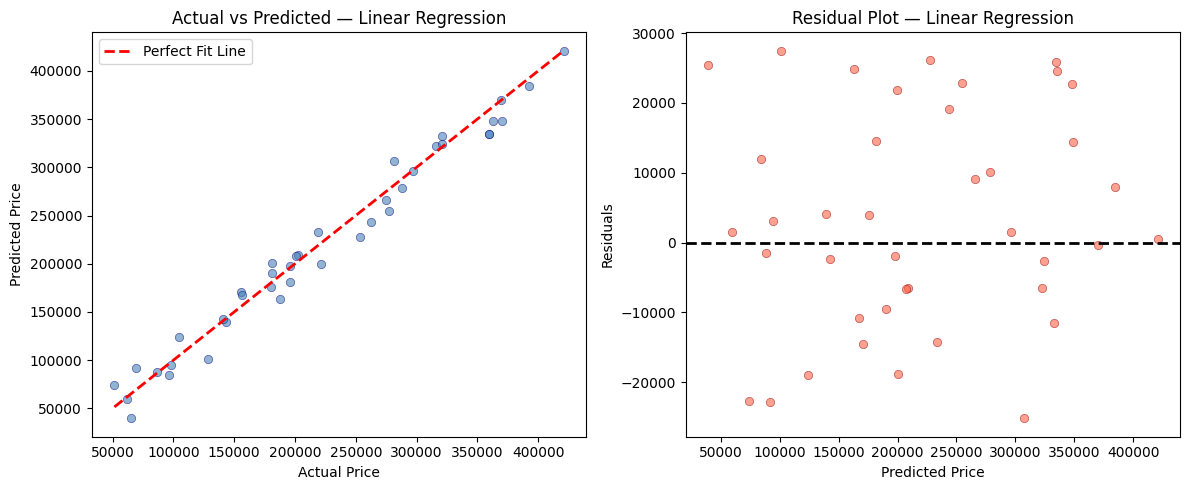

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_lr, y_pred_lr, color='steelblue', alpha=0.6, edgecolors='navy', linewidths=0.5)
plt.plot([y_test_lr.min(), y_test_lr.max()],
         [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_test_lr - y_pred_lr
plt.scatter(y_pred_lr, residuals, color='tomato', alpha=0.6, edgecolors='darkred', linewidths=0.5)
plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot — Linear Regression')

plt.tight_layout()
plt.show()

---
# Part 2: Logistic Regression
### Goal — Predict High (1) or Low (0) Price (Binary Classification)

## Step 6A: Train-Test Split, Scaling and Model Training

In [22]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_logistic, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled  = scaler.transform(X_test_log)

print(f'Train size : {X_train_log.shape[0]} samples')
print(f'Test size  : {X_test_log.shape[0]} samples')

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_log)

print('\nLogistic Regression model trained successfully!')

Train size : 160 samples
Test size  : 40 samples

Logistic Regression model trained successfully!


## Step 6B: Predictions and Evaluation

In [23]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

mse_log = mean_squared_error(y_test_log, y_pred_log)
r2_log  = r2_score(y_test_log, y_pred_log)
acc_log = accuracy_score(y_test_log, y_pred_log)

print('=' * 48)
print('     LOGISTIC REGRESSION — METRICS')
print('=' * 48)
print(f'  Mean Squared Error  (MSE)  : {mse_log:.4f}')
print(f'  R-Squared Score     (R2)   : {r2_log:.4f}')
print(f'  Accuracy                   : {acc_log:.4f}  ({acc_log*100:.2f}%)')
print('=' * 48)

print('\nClassification Report:')
print(classification_report(y_test_log, y_pred_log, target_names=['Low Price', 'High Price']))

     LOGISTIC REGRESSION — METRICS
  Mean Squared Error  (MSE)  : 0.0750
  R-Squared Score     (R2)   : 0.6931
  Accuracy                   : 0.9250  (92.50%)

Classification Report:
              precision    recall  f1-score   support

   Low Price       0.88      1.00      0.94        23
  High Price       1.00      0.82      0.90        17

    accuracy                           0.93        40
   macro avg       0.94      0.91      0.92        40
weighted avg       0.93      0.93      0.92        40



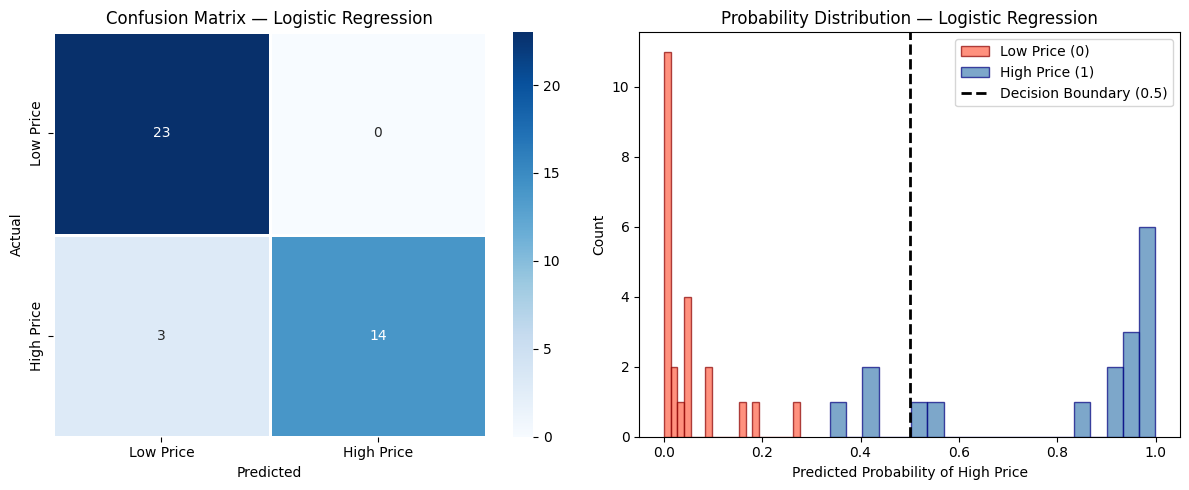

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Price', 'High Price'],
            yticklabels=['Low Price', 'High Price'],
            linewidths=1, linecolor='white')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')

plt.subplot(1, 2, 2)
plt.hist(y_prob_log[y_test_log == 0], bins=20, alpha=0.7,
         label='Low Price (0)', color='tomato', edgecolor='darkred')
plt.hist(y_prob_log[y_test_log == 1], bins=20, alpha=0.7,
         label='High Price (1)', color='steelblue', edgecolor='navy')
plt.axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Boundary (0.5)')
plt.xlabel('Predicted Probability of High Price')
plt.ylabel('Count')
plt.title('Probability Distribution — Logistic Regression')
plt.legend()

plt.tight_layout()
plt.show()

---
## Step 7: Final Comparison Summary

In [25]:
print('\n' + '=' * 58)
print('            FINAL COMPARISON SUMMARY')
print('=' * 58)
print(f'{"Metric":<32} {"Linear Reg":>12} {"Logistic Reg":>12}')
print('-' * 58)
print(f'{"Mean Squared Error (MSE)":<32} {mse_lr:>12.4f} {mse_log:>12.4f}')
print(f'{"R-Squared Score (R2)":<32} {r2_lr:>12.4f} {r2_log:>12.4f}')
print(f'{"Task Type":<32} {"Regression":>12} {"Classification":>12}')
print(f'{"Target Variable":<32} {"Price":>12} {"High/Low":>12}')
print('=' * 58)
print('\nNotes:')
print('  - MSE for Logistic Regression = fraction of misclassified samples')
print('  - R2 for Logistic Regression  = variance explained in binary target')
print('  - R2 for Linear Regression    = primary goodness-of-fit metric')


            FINAL COMPARISON SUMMARY
Metric                             Linear Reg Logistic Reg
----------------------------------------------------------
Mean Squared Error (MSE)         250430249.8457       0.0750
R-Squared Score (R2)                   0.9765       0.6931
Task Type                          Regression Classification
Target Variable                         Price     High/Low

Notes:
  - MSE for Logistic Regression = fraction of misclassified samples
  - R2 for Logistic Regression  = variance explained in binary target
  - R2 for Linear Regression    = primary goodness-of-fit metric


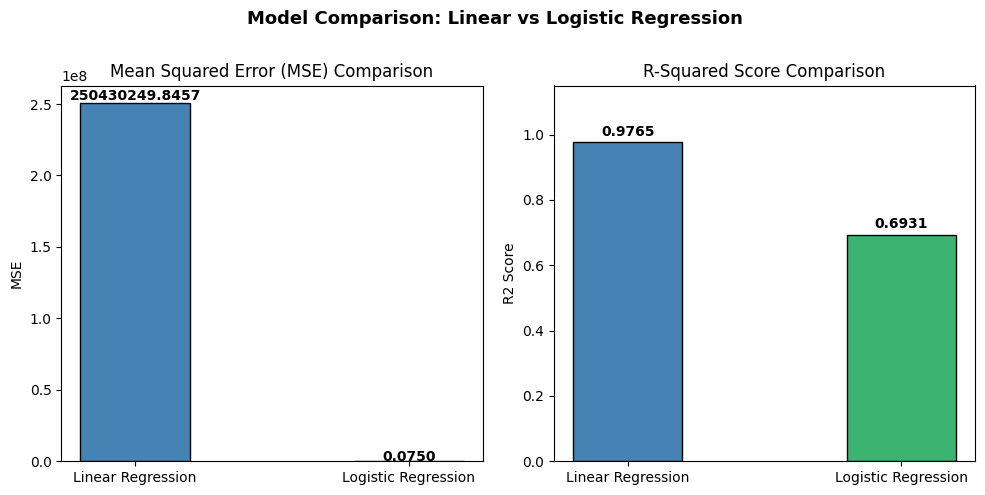

Task complete. Both Linear and Logistic Regression implemented with MSE and R-Squared Score.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
models = ['Linear Regression', 'Logistic Regression']
colors = ['steelblue', 'mediumseagreen']

axes[0].bar(models, [mse_lr, mse_log], color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Mean Squared Error (MSE) Comparison')
axes[0].set_ylabel('MSE')
for i, v in enumerate([mse_lr, mse_log]):
    axes[0].text(i, v * 1.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(models, [r2_lr, r2_log], color=colors, edgecolor='black', width=0.4)
axes[1].set_title('R-Squared Score Comparison')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0, 1.15)
for i, v in enumerate([r2_lr, r2_log]):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison: Linear vs Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Task complete. Both Linear and Logistic Regression implemented with MSE and R-Squared Score.')